In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

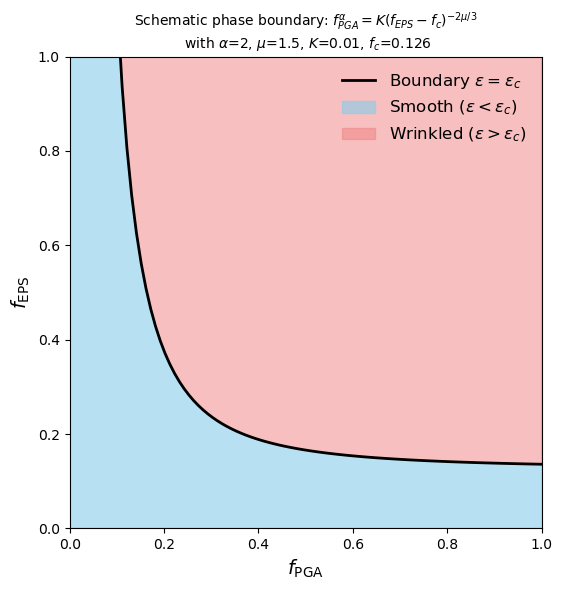

In [2]:
def boundary(x, alpha, mu, K, f_c):
    y = ((K / (x) ** alpha)) ** (3 / (2 * mu)) + f_c
#     y = K * x ** /(-3 * alpha / (2 * mu)) + f_c
    return y

def plot_boundary(alpha, mu, K):
    f_PGA = np.linspace(1e-6, 1, 100)
    f_c = 0.126

    plt.figure(figsize=(6,6))
    f_EPS = boundary(f_PGA, alpha, mu, K, f_c)   
    plt.plot(f_PGA, f_EPS, color="black", linewidth=2, label=r"Boundary $\epsilon = \epsilon_c$")
    plt.fill_between(f_PGA, 0, f_EPS, color="skyblue", alpha=0.6, label=r"Smooth ($\epsilon < \epsilon_c$)")
    plt.fill_between(f_PGA, f_EPS, 1, color="lightcoral", alpha=0.5, label=r"Wrinkled ($\epsilon > \epsilon_c$)")
    plt.xlabel(r"$f_{\mathrm{PGA}}$", fontsize=14)
    plt.ylabel(r"$f_{\mathrm{EPS}}$", fontsize=14)
    plt.title(
        rf"Schematic phase boundary: $f_{{PGA}}^{{\alpha}} = K(f_{{EPS}}-f_c)^{{-2\mu/3}}$" 
        f"\n"+rf" with $\alpha$={alpha}, $\mu$={mu}, $K$={K}, $f_c$={f_c}",
        fontsize=10
    )
    plt.legend(frameon=False, fontsize=12)
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout() 
alpha = 2
mu = 1.5   
K = 0.01
plot_boundary(alpha, mu, K)
plt.show()

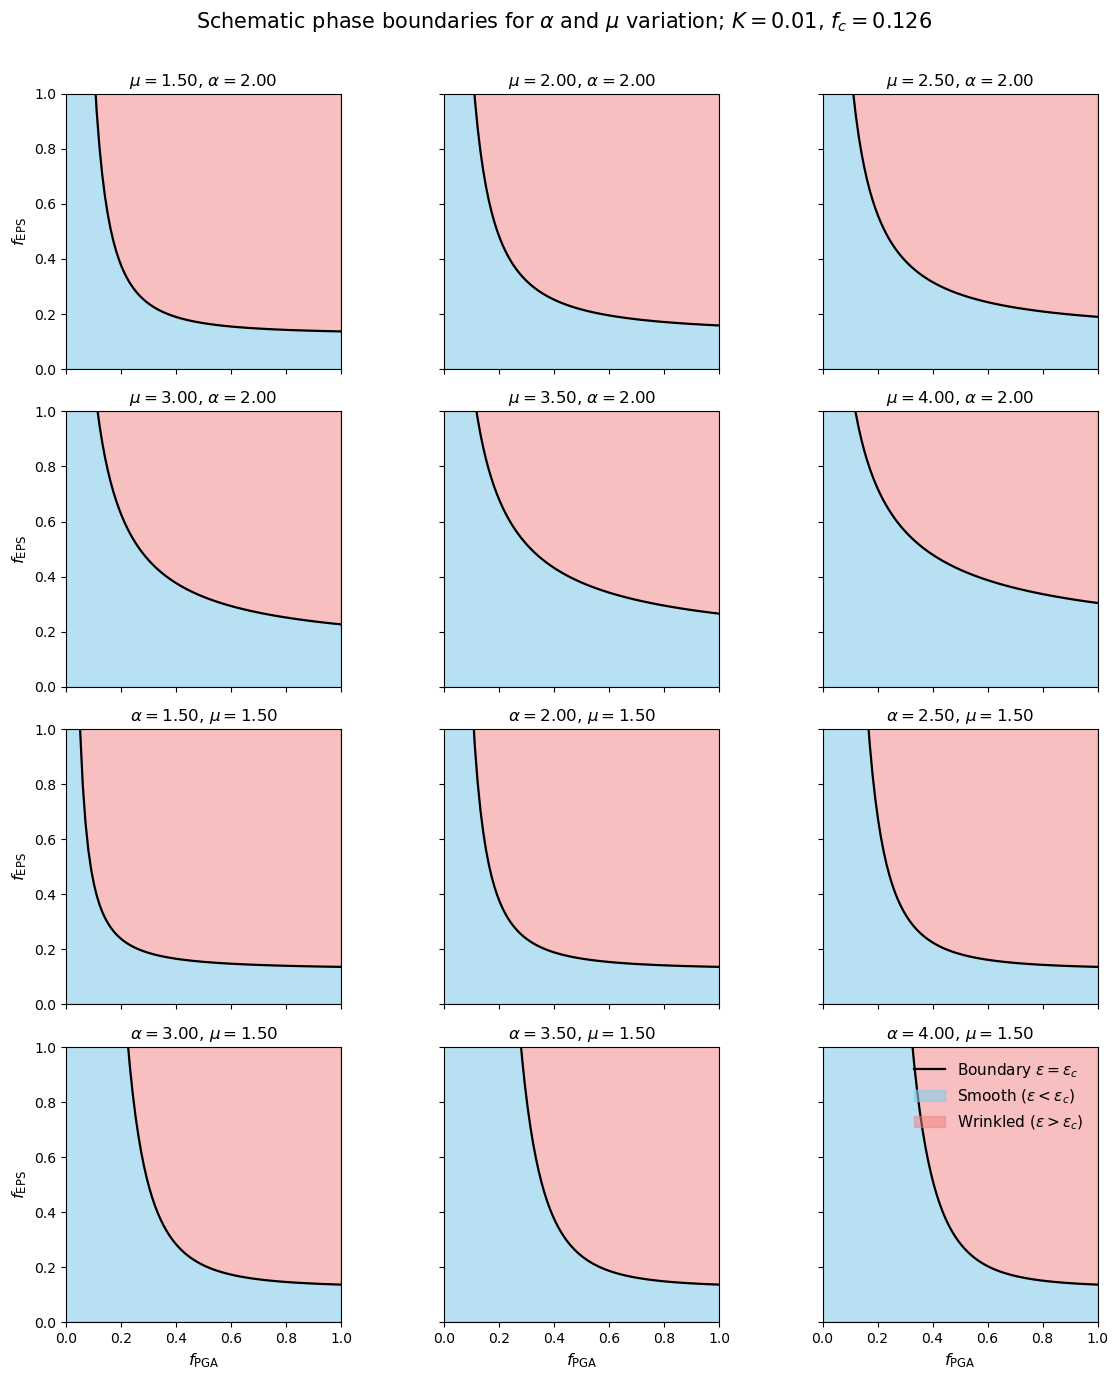

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def boundary(x, alpha, mu, K, f_c):
    y = ((K / (x) ** alpha)) ** (3 / (2 * mu)) + f_c
    return y

# Parameters
K = 0.01
f_c = 0.126
f_PGA = np.linspace(0.000001, 1, 100)

# Vary mu with fixed alpha
alpha_fixed = 2.0
mu_values = np.linspace(1.5, 4.0, 6)

# Vary alpha with fixed mu
mu_fixed = 1.5
alpha_values = np.linspace(1.5, 4.0, 6)

fig, axs = plt.subplots(4, 3, figsize=(12, 14), sharex=True, sharey=True)
axs = axs.flatten()

for i in range(12):
    ax = axs[i]
    if i < 6:
        mu = mu_values[i]
        y = boundary(f_PGA, alpha_fixed, mu, K, f_c)
        title = fr"$\mu={mu:.2f}$, $\alpha={alpha_fixed:.2f}$"
    else:
        alpha = alpha_values[i-6]
        y = boundary(f_PGA, alpha, mu_fixed, K, f_c)
        title = fr"$\alpha={alpha:.2f}$, $\mu={mu_fixed:.2f}$"
        
    line, = ax.plot(f_PGA, y, color="black", linewidth=1.6)
    fill1 = ax.fill_between(f_PGA, 0, y, color="skyblue", alpha=0.6)
    fill2 = ax.fill_between(f_PGA, y, 1, color="lightcoral", alpha=0.5)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=12)
    ax.tick_params(labelsize=10)
    if i % 3 == 0:
        ax.set_ylabel(r"$f_{\mathrm{EPS}}$", fontsize=12)
    if i >= 9:
        ax.set_xlabel(r"$f_{\mathrm{PGA}}$", fontsize=12)
    # Only add legend to last subplot
    if i == 11:
        handles = [line, fill1, fill2]
        labels = [
            r"Boundary $\epsilon = \epsilon_c$",
            r"Smooth ($\epsilon < \epsilon_c$)",
            r"Wrinkled ($\epsilon > \epsilon_c$)"
        ]
        ax.legend(handles, labels, frameon=False, fontsize=11, loc="upper right")

fig.suptitle(
    r"Schematic phase boundaries for $\alpha$ and $\mu$ variation; $K={}$, $f_c={}$".format(K, f_c),
    fontsize=15
)
plt.tight_layout(rect=[0, 0, 1, 0.97], pad=0.85)
plt.show()

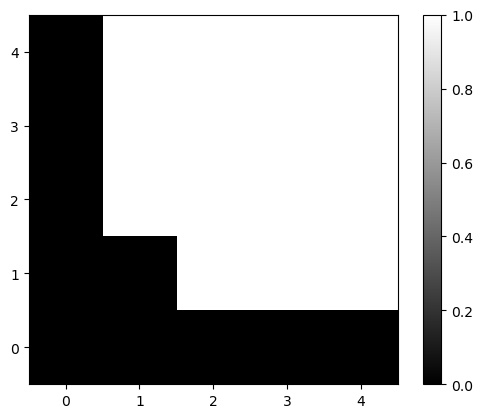

In [5]:
#on a 5x5 grid model predictions
ratios = np.linspace(0, 1, 5)
alpha = 2
mu = 1.5
K = 0.01
f_c = 0.126
phase_portrait = np.zeros((5,5))
for i in range(len(ratios)):
    for j in range(len(ratios)):
        f_EPS = ratios[i]
        f_PGA = ratios[j]

        epsilon = f_PGA ** alpha 
        if f_EPS >=f_c: 
            epsilon_c = K / (f_EPS - f_c) ** (2 * mu / 3)
            phase_portrait[i][j] = 1 if (epsilon >=epsilon_c) else 0

plt.imshow(phase_portrait, origin = "lower", cmap= "gray")
plt.colorbar()
plt.show()